# Создание модели для пресказания тональности комментариев

### Необходимо проделать:
1. Проанализировать датасет.
2. Провести предварительную обработку текстов размеченного датасета: очистка 
данных, удаление стоп-слов, специальных символов, лишних пробелов; перевод в 
нижний регистр; лемматизация/стемминг.
3. Провести тематическое моделирование для каждой тональности комментариев: 
определите слова, специфичные для каждого класса: облако слов, модели 
тематического моделирования.
4. Векторизация. Получить векторное представление текстов.
5. Провести обучение модели на полученных векторах. Рассмотреть не менее 3 моделей нейронной сети.
Проведисти оценку качества моделей.

### 1. Подключение библиотек

In [1]:
import pandas as pd
import numpy as np
import re
import string
import nltk
import pymorphy3

import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer

from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.decomposition import TruncatedSVD

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV

from keras.models import Model
from tensorflow.keras.models import Sequential

from keras.layers import Input, Dense, Embedding, SpatialDropout1D, concatenate
from keras.layers import GRU, Bidirectional, GlobalAveragePooling1D, GlobalMaxPooling1D
from keras.preprocessing import text, sequence
from keras.callbacks import Callback

### 2. Подключение датасета

In [2]:
df = pd.read_csv("C:\\Users\\79174\\Downloads\\archive (3)\\labeled.csv",  low_memory=False) #low_memory определение типа данных столбцов после загрузки всех записей
df

,comment,toxic
0,"Верблюдов-то за что? Дебилы, бл...\n",1.0
1,"Хохлы, это отдушина затюканого россиянина, мол...",1.0
2,Собаке - собачья смерть\n,1.0
3,"Страницу обнови, дебил. Это тоже не оскорблени...",1.0
4,"тебя не убедил 6-страничный пдф в том, что Скр...",1.0
...,...,...
14407,Вонючий совковый скот прибежал и ноет. А вот и...,1.0
14408,А кого любить? Гоблина тупорылого что-ли? Или ...,1.0
14409,"Посмотрел Утомленных солнцем 2. И оказалось, ч...",0.0
14410,КРЫМОТРЕД НАРУШАЕТ ПРАВИЛА РАЗДЕЛА Т.К В НЕМ Н...,1.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14412 entries, 0 to 14411
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   comment  14412 non-null  object 
 1   toxic    14412 non-null  float64
dtypes: float64(1), object(1)
memory usage: 225.3+ KB


In [4]:
df.duplicated().sum()

0

In [5]:
df.describe()

,toxic
count,14412.000000
mean,0.334860
std,0.471958
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


### 3. Предварительная обработка текстов

In [6]:
df.comment[12]

'Почитайте посты у этого автора,может найдете что нибудь полезное. Надеюсь помог) https: pikabu.ru story obyichnyie budni dezsluzhbyi 4932098\n'

In [7]:
st = '\xa0—'
custom_punctuation = string.punctuation + '«»'
def remove_othersymbol(text):
    return ''.join([ch if ch not in st else ' ' for ch in text])
    
def remove_punctuation(text):
    return ''.join([ch for ch in text if ch not in custom_punctuation])
    
def remove_numbers(text): 
    return ''.join([i if not i.isdigit() else ' ' for i in text])
    
def remove_multiple_spaces(text): 
    return re.sub(r'\s+', ' ', text, flags=re.I)

In [8]:
df['clean_comment'] = [remove_multiple_spaces(remove_numbers(remove_othersymbol(remove_punctuation(text.lower())))) for text in df['comment']]

In [9]:
df.clean_comment[12]

'почитайте посты у этого автораможет найдете что нибудь полезное надеюсь помог https pikaburu story obyichnyie budni dezsluzhbyi '

In [10]:
russian_stopwords = stopwords.words("russian") 

In [11]:
russian_stopwords.extend(['т.д.', 'т', 'д', 'это','который','которые','которых','свой','своём','всем','всё','её','оба','ещё','должный','должные','должных']) 

In [12]:
def remove_stopwords(text):
    if not isinstance(text, str):
        return text
    
    words = text.split()
    filtered_words = [word for word in words if word.lower() not in russian_stopwords]
    
    return ' '.join(filtered_words)

In [13]:
df['prep_comment'] = df['clean_comment'].apply(remove_stopwords)

In [14]:
df

,comment,toxic,clean_comment,prep_comment
0,"Верблюдов-то за что? Дебилы, бл...\n",1.0,верблюдовто за что дебилы бл,верблюдовто дебилы бл
1,"Хохлы, это отдушина затюканого россиянина, мол...",1.0,хохлы это отдушина затюканого россиянина мол в...,хохлы отдушина затюканого россиянина мол вон х...
2,Собаке - собачья смерть\n,1.0,собаке собачья смерть,собаке собачья смерть
3,"Страницу обнови, дебил. Это тоже не оскорблени...",1.0,страницу обнови дебил это тоже не оскорбление ...,страницу обнови дебил оскорбление доказанный ф...
4,"тебя не убедил 6-страничный пдф в том, что Скр...",1.0,тебя не убедил страничный пдф в том что скрипа...,убедил страничный пдф скрипалей отравила росси...
...,...,...,...,...
14407,Вонючий совковый скот прибежал и ноет. А вот и...,1.0,вонючий совковый скот прибежал и ноет а вот и ...,вонючий совковый скот прибежал ноет сторонник ...
14408,А кого любить? Гоблина тупорылого что-ли? Или ...,1.0,а кого любить гоблина тупорылого чтоли или как...,кого любить гоблина тупорылого чтоли какуюнибу...
14409,"Посмотрел Утомленных солнцем 2. И оказалось, ч...",0.0,посмотрел утомленных солнцем и оказалось что э...,посмотрел утомленных солнцем оказалось хороший...
14410,КРЫМОТРЕД НАРУШАЕТ ПРАВИЛА РАЗДЕЛА Т.К В НЕМ Н...,1.0,крымотред нарушает правила раздела тк в нем не...,крымотред нарушает правила раздела тк нем обсу...


In [15]:
morph = pymorphy3.MorphAnalyzer(lang='ru')

In [16]:
%%time
lemm_texts_list = []
for text in (df['prep_comment']):
    try:
        tokens = word_tokenize(text)
        res = list()
        for word in tokens:
            p = morph.parse(word)[0]
            res.append(p.normal_form)
        text = " ".join(res)
        lemm_texts_list.append(text)
    except Exception as e:
        print(e)
    
df['lemm_comment'] = lemm_texts_list

CPU times: total: 30.5 s
Wall time: 33.6 s


In [17]:
df.lemm_comment[12]

'почитать пост авторамочь найти полезный надеяться помочь https pikaburu story obyichnyie budni dezsluzhbyi'

In [18]:
df

,comment,toxic,clean_comment,prep_comment,lemm_comment
0,"Верблюдов-то за что? Дебилы, бл...\n",1.0,верблюдовто за что дебилы бл,верблюдовто дебилы бл,верблюдовто дебил бл
1,"Хохлы, это отдушина затюканого россиянина, мол...",1.0,хохлы это отдушина затюканого россиянина мол в...,хохлы отдушина затюканого россиянина мол вон х...,хохол отдушина затюканый россиянин мол вон хох...
2,Собаке - собачья смерть\n,1.0,собаке собачья смерть,собаке собачья смерть,собака собачий смерть
3,"Страницу обнови, дебил. Это тоже не оскорблени...",1.0,страницу обнови дебил это тоже не оскорбление ...,страницу обнови дебил оскорбление доказанный ф...,страница обновить дебил оскорбление доказать ф...
4,"тебя не убедил 6-страничный пдф в том, что Скр...",1.0,тебя не убедил страничный пдф в том что скрипа...,убедил страничный пдф скрипалей отравила росси...,убедить страничный пдф скрипаль отравить росси...
...,...,...,...,...,...
14407,Вонючий совковый скот прибежал и ноет. А вот и...,1.0,вонючий совковый скот прибежал и ноет а вот и ...,вонючий совковый скот прибежал ноет сторонник ...,вонючий совковый скот прибежать ныть сторонник...
14408,А кого любить? Гоблина тупорылого что-ли? Или ...,1.0,а кого любить гоблина тупорылого чтоли или как...,кого любить гоблина тупорылого чтоли какуюнибу...,кто любить гоблин тупорылый чтоль какуюнибудь ...
14409,"Посмотрел Утомленных солнцем 2. И оказалось, ч...",0.0,посмотрел утомленных солнцем и оказалось что э...,посмотрел утомленных солнцем оказалось хороший...,посмотреть утомлённый солнце оказаться хороший...
14410,КРЫМОТРЕД НАРУШАЕТ ПРАВИЛА РАЗДЕЛА Т.К В НЕМ Н...,1.0,крымотред нарушает правила раздела тк в нем не...,крымотред нарушает правила раздела тк нем обсу...,крымотред нарушать правило раздел тк немой обс...


In [19]:
def tokenize(text):
    t = word_tokenize(text)
    tokens = [token for token in t if token not in russian_stopwords]
    text = " ".join(tokens)
    return text

In [20]:
df['tokenize_comment'] = [tokenize(text) for text in df['lemm_comment']]

In [21]:
df

,comment,toxic,clean_comment,prep_comment,lemm_comment,tokenize_comment
0,"Верблюдов-то за что? Дебилы, бл...\n",1.0,верблюдовто за что дебилы бл,верблюдовто дебилы бл,верблюдовто дебил бл,верблюдовто дебил бл
1,"Хохлы, это отдушина затюканого россиянина, мол...",1.0,хохлы это отдушина затюканого россиянина мол в...,хохлы отдушина затюканого россиянина мол вон х...,хохол отдушина затюканый россиянин мол вон хох...,хохол отдушина затюканый россиянин мол вон хох...
2,Собаке - собачья смерть\n,1.0,собаке собачья смерть,собаке собачья смерть,собака собачий смерть,собака собачий смерть
3,"Страницу обнови, дебил. Это тоже не оскорблени...",1.0,страницу обнови дебил это тоже не оскорбление ...,страницу обнови дебил оскорбление доказанный ф...,страница обновить дебил оскорбление доказать ф...,страница обновить дебил оскорбление доказать ф...
4,"тебя не убедил 6-страничный пдф в том, что Скр...",1.0,тебя не убедил страничный пдф в том что скрипа...,убедил страничный пдф скрипалей отравила росси...,убедить страничный пдф скрипаль отравить росси...,убедить страничный пдф скрипаль отравить росси...
...,...,...,...,...,...,...
14407,Вонючий совковый скот прибежал и ноет. А вот и...,1.0,вонючий совковый скот прибежал и ноет а вот и ...,вонючий совковый скот прибежал ноет сторонник ...,вонючий совковый скот прибежать ныть сторонник...,вонючий совковый скот прибежать ныть сторонник...
14408,А кого любить? Гоблина тупорылого что-ли? Или ...,1.0,а кого любить гоблина тупорылого чтоли или как...,кого любить гоблина тупорылого чтоли какуюнибу...,кто любить гоблин тупорылый чтоль какуюнибудь ...,любить гоблин тупорылый чтоль какуюнибудь прод...
14409,"Посмотрел Утомленных солнцем 2. И оказалось, ч...",0.0,посмотрел утомленных солнцем и оказалось что э...,посмотрел утомленных солнцем оказалось хороший...,посмотреть утомлённый солнце оказаться хороший...,посмотреть утомлённый солнце оказаться хороший...
14410,КРЫМОТРЕД НАРУШАЕТ ПРАВИЛА РАЗДЕЛА Т.К В НЕМ Н...,1.0,крымотред нарушает правила раздела тк в нем не...,крымотред нарушает правила раздела тк нем обсу...,крымотред нарушать правило раздел тк немой обс...,крымотред нарушать правило раздел тк немой обс...


### 4. Тематическое моделирование

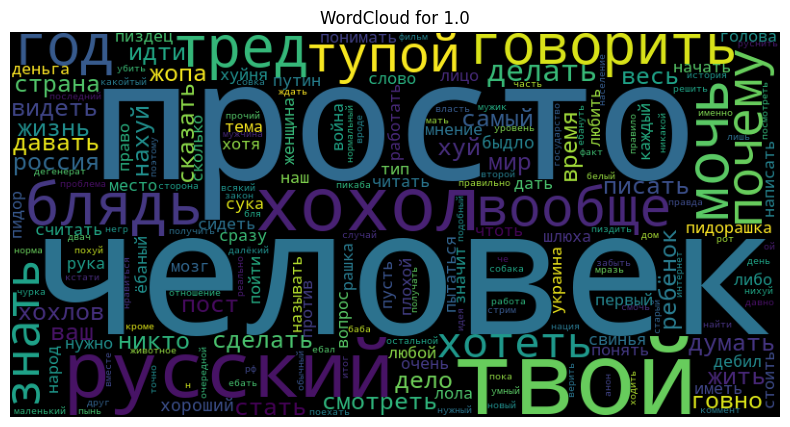

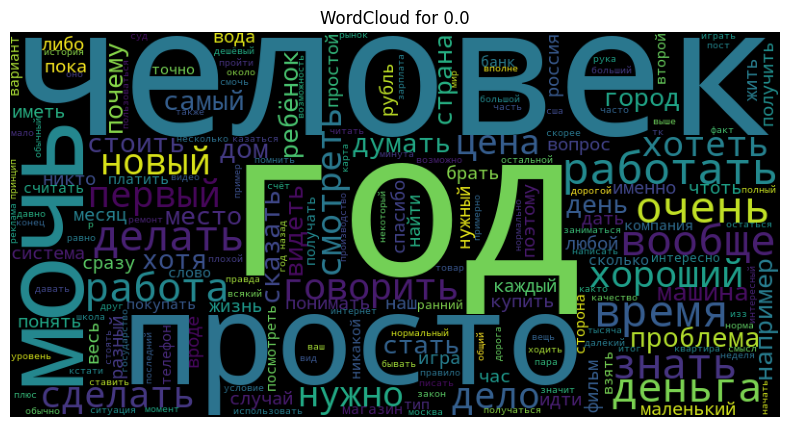

In [22]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_wordcloud(text, toxic):
    wordcloud = WordCloud(width=800, height=400).generate(text)
    plt.figure(figsize=(10, 5))
    plt.title(f'WordCloud for {toxic}')
    plt.imshow(wordcloud)
    plt.axis('off')
    plt.show()

for lang in df['toxic'].unique():
    text = ' '.join(df[df['toxic'] == lang]['tokenize_comment'])
    plot_wordcloud(text, lang)

In [23]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import gensim

vectorizer = CountVectorizer(max_features=1000)
X = vectorizer.fit_transform(df['tokenize_comment'])

lda = LatentDirichletAllocation(n_components=5)
lda.fit(X)

for i, topic in enumerate(lda.components_):
    print(f'Topic {i}:')
    print([vectorizer.get_feature_names_out()[i] for i in topic.argsort()[-10:]])

Topic 0:
['место', 'либо', 'читать', 'хохол', 'спасибо', 'человек', 'думать', 'русский', 'видеть', 'просто']
Topic 1:
['хуй', 'говорить', 'делать', 'хороший', 'блядь', 'человек', 'друг', 'тред', 'идти', 'твой']
Topic 2:
['банк', 'наш', 'закон', 'деньга', 'работа', 'мочь', 'россия', 'дать', 'страна', 'год']
Topic 3:
['месяц', 'дом', 'рубль', 'час', 'работать', 'время', 'цена', 'день', 'стоить', 'год']
Topic 4:
['вообще', 'дело', 'знать', 'ребёнок', 'время', 'смотреть', 'мочь', 'очень', 'просто', 'человек']


In [24]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import pandas as pd

languages = df['toxic'].unique()

for lang in languages:
    print(f"\n=== Топ-темы для языка: {lang} ===")
    
    lang_texts = df[df['toxic'] == lang]['tokenize_comment']
    
    vectorizer = CountVectorizer(max_features=500, 
                               ngram_range=(1, 2))
    
    X_lang = vectorizer.fit_transform(lang_texts)
    
    lda = LatentDirichletAllocation(n_components=5, 
                                  random_state=42)
    lda.fit(X_lang)
    
    for topic_idx, topic in enumerate(lda.components_):
        print(f"\nТема {topic_idx + 1}:")
        top_words = [vectorizer.get_feature_names_out()[i] 
                    for i in topic.argsort()[-10:]]
        print(", ".join(top_words))


=== Топ-темы для языка: 1.0 ===

Тема 1:
мозг, путин, хороший, нахуй, сука, идти, давать, хуйня, смотреть, блядь

Тема 2:
россия, терпеть, свинья, пиздец, быдло, говорить, хохлов, просто, хохол, русский

Тема 3:
считать, дебил, пидорашка, мочь, самый, мир, почему, жить, человек, год

Тема 4:
голова, место, сказать, ваш, лицо, пойти, пост, тред, хуй, твой

Тема 5:
стать, либо, друг, никто, делать, сделать, ребёнок, хотеть, человек, тупой

=== Топ-темы для языка: 0.0 ===

Тема 1:
вроде, фильм, нужно, спасибо, просто, сделать, почему, вообще, делать, очень

Тема 2:
назад, купить, платить, проблема, видеть, очень, ребёнок, просто, знать, год

Тема 3:
просто, либо, любой, место, цена, случай, иметь, мочь, деньга, человек

Тема 4:
система, последний, сша, россия, город, дело, работа, страна, год, время

Тема 5:
пара, часть, игра, вода, рубль, хороший, месяц, стоить, день, год


В токсичных комментариях доминирует политическая вражда, выраженная через оскорбительную лексику, национальные ярлыки и агрессивный сленг. Это указывает на конфликтный, эмоционально заряженный характер обсуждений.

В хороших комментариях преобладают бытовые и нейтральные темы — работа, деньги, дети, покупки, повседневные вопросы. Тон — конструктивный, без личных нападок.

### 5. Векторизация данных

In [25]:
%%time
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_text = tfidf_vectorizer.fit_transform(df['tokenize_comment'])
y = df['toxic']

CPU times: total: 1.11 s
Wall time: 1.1 s


In [26]:
X_text.shape

(14412, 5000)

In [27]:
print(X_text)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 153148 stored elements and shape (14412, 5000)>
  Coords	Values
  (0, 799)	1.0
  (1, 4750)	0.267395669194846
  (1, 3667)	0.3796088657025208
  (1, 1978)	0.35930345261357705
  (1, 466)	0.35017291474067835
  (1, 4748)	0.6010694013934255
  (1, 2842)	0.26379868592373035
  (1, 3240)	0.3190649650327168
  (2, 3949)	0.5112930913438828
  (2, 3950)	0.6770487058333738
  (2, 3918)	0.5293244984632482
  (3, 799)	0.3121290379965013
  (3, 4180)	0.3716508285964818
  (3, 2506)	0.3836017457137721
  (3, 901)	0.3577155618319979
  (3, 4646)	0.2820118591918714
  (3, 4854)	0.3132621970281713
  (3, 2803)	0.2618417206218472
  (3, 328)	0.3168192390797444
  (3, 4291)	0.2587658586912789
  (3, 962)	0.27528389601683234
  (4, 4471)	0.5852959647284084
  (4, 3666)	0.3553515429464827
  (4, 967)	0.3251291907531036
  (4, 3454)	0.3940839143659248
  :	:
  (14410, 2130)	0.24304747005931054
  (14410, 3992)	0.20787931862579767
  (14410, 4819)	0.25848891190463524
  (1

In [28]:
tfidf_vectorizer.get_feature_names_out()[:100]

array(['and', 'boeing', 'crimes', 'facebook', 'gifx', 'https', 'ip', 'it',
       'of', 'phd', 'ps', 'samsung', 'state', 'the', 'usb', 'wifi',
       'windows', 'yota', 'абзац', 'абонент', 'абсолютно', 'абсолютный',
       'абу', 'аварийный', 'авария', 'аватарка', 'аватарка истекать',
       'август', 'авиакомпания', 'австралия', 'авто', 'автобус',
       'автомат', 'автоматически', 'автоматический', 'автомобиль',
       'автор', 'авторитет', 'ага', 'агент', 'агентство', 'агрессивность',
       'агрессивный', 'агрессия', 'ад', 'адекватный', 'админ',
       'администрация', 'адрес', 'аж', 'азиат', 'азиатский', 'азия', 'ай',
       'ай ай', 'ай просто', 'айфон', 'академик', 'академия', 'аккаунт',
       'аккумулятор', 'аккуратно', 'акт', 'активировать', 'активно',
       'активность', 'активный', 'актриса', 'актуальный', 'актёр',
       'акция', 'алгоритм', 'алекс', 'александр', 'али', 'алкаш',
       'алкоголь', 'аллергия', 'алсый', 'альбом', 'альтернатива',
       'америка', 'американе

In [59]:
import pickle

with open('vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)

### 6. Обучение моделей

### Dense

In [29]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from sklearn.metrics import classification_report

X = X_text
y = df['toxic'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
X_train = X_train.toarray()
X_test = X_test.toarray()

In [31]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

In [32]:
class_weight_dict = dict(enumerate(class_weights))
print(f"Веса классов: {class_weight_dict}")

Веса классов: {0: 0.7517605633802817, 1: 1.493006993006993}


In [33]:

model = tf.keras.Sequential([
    tf.keras.layers.Dense(256, input_shape=(5000,), activation='relu', name='input'),
    tf.keras.layers.Dropout(0.3),
    
    tf.keras.layers.Dense(128, activation='relu', name='hidden1'),
    tf.keras.layers.Dropout(0.3),
    
    tf.keras.layers.Dense(64, activation='relu', name='hidden2'),
    tf.keras.layers.Dropout(0.3),
    
    tf.keras.layers.Dense(32, activation='relu', name='hidden3'),
    
    tf.keras.layers.Dense(1, activation='sigmoid', name='output')
])

In [34]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', 
             tf.keras.metrics.Precision(),
             tf.keras.metrics.Recall(),
             tf.keras.metrics.AUC(name='auc')]
)

In [35]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

In [36]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
145/145 [==============================] - 4s 18ms/step - loss: 0.5083 - accuracy: 0.7768 - precision: 0.6988 - recall: 0.5884 - auc: 0.8343 - val_loss: 0.4144 - val_accuracy: 0.8170 - val_precision: 0.6770 - val_recall: 0.8590 - val_auc: 0.9136
Epoch 2/50
145/145 [==============================] - 2s 15ms/step - loss: 0.2473 - accuracy: 0.9023 - precision: 0.8209 - recall: 0.9066 - auc: 0.9620 - val_loss: 0.4021 - val_accuracy: 0.8265 - val_precision: 0.6959 - val_recall: 0.8486 - val_auc: 0.9122
Epoch 3/50
145/145 [==============================] - 2s 15ms/step - loss: 0.1400 - accuracy: 0.9496 - precision: 0.8999 - recall: 0.9561 - auc: 0.9867 - val_loss: 0.4796 - val_accuracy: 0.8465 - val_precision: 0.7861 - val_recall: 0.7389 - val_auc: 0.9037
Epoch 4/50
145/145 [==============================] - 2s 15ms/step - loss: 0.0724 - accuracy: 0.9752 - precision: 0.9467 - recall: 0.9813 - auc: 0.9961 - val_loss: 0.5751 - val_accuracy: 0.8387 - val_precision: 0.7356 - val_recal

In [37]:
sample_indices = [0, 1, 2, 3, 4]
sample_comments = df.iloc[sample_indices]['tokenize_comment'].values
sample_X = X_test[sample_indices]
sample_y_true = y_test[sample_indices]

In [38]:
predictions = model.predict(sample_X)

1/1 [==============================] - 0s 105ms/step


In [40]:
test = np.argmax(predictions,axis=1)
prediction = test.flatten()

In [41]:
prediction

array([0, 0, 0, 0, 0], dtype=int64)

In [42]:
y_pred = model.predict(X_test)

y_pred_binary = (y_pred > 0.5).astype(int)

print(classification_report(y_test, y_pred_binary))

91/91 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

         0.0       0.92      0.83      0.87      1918
         1.0       0.72      0.86      0.78       965

    accuracy                           0.84      2883
   macro avg       0.82      0.85      0.83      2883
weighted avg       0.85      0.84      0.84      2883



In [43]:
model.save('model.keras')

### RNN

In [44]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Embedding, LSTM, GRU, SimpleRNN, Dense, Dropout, Bidirectional

X = df['tokenize_comment'].values
y = df['toxic'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

max_words = 10000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Паддинг
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

In [45]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print(f"Веса классов: {class_weight_dict}")

Веса классов: {0: 0.7517605633802817, 1: 1.493006993006993}


In [46]:
model_rnn = tf.keras.Sequential([
    Embedding(max_words, 64, input_length=max_len, name='embedding'),
    SimpleRNN(32, dropout=0.3, return_sequences=False, name='simple_rnn'),
    Dense(16, activation='relu', name='dense1'),
    Dropout(0.2, name='dropout1'),
    Dense(1, activation='sigmoid', name='output')
])

In [47]:
model_rnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(),
             tf.keras.metrics.Recall(),
             tf.keras.metrics.AUC(name='auc')]
)

In [48]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [49]:
history_rnn = model_rnn.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
145/145 [==============================] - 6s 26ms/step - loss: 0.6962 - accuracy: 0.5038 - precision_1: 0.3290 - recall_1: 0.4604 - auc: 0.4877 - val_loss: 0.6976 - val_accuracy: 0.3335 - val_precision_1: 0.3313 - val_recall_1: 0.9883 - val_auc: 0.4859
Epoch 2/20
145/145 [==============================] - 3s 23ms/step - loss: 0.6917 - accuracy: 0.5241 - precision_1: 0.3578 - recall_1: 0.5260 - auc: 0.5362 - val_loss: 0.6775 - val_accuracy: 0.5785 - val_precision_1: 0.4077 - val_recall_1: 0.5940 - val_auc: 0.6064
Epoch 3/20
145/145 [==============================] - 3s 23ms/step - loss: 0.6895 - accuracy: 0.5331 - precision_1: 0.3571 - recall_1: 0.4889 - auc: 0.5409 - val_loss: 0.7080 - val_accuracy: 0.3343 - val_precision_1: 0.3322 - val_recall_1: 0.9935 - val_auc: 0.4990
Epoch 4/20
145/145 [==============================] - 3s 24ms/step - loss: 0.6919 - accuracy: 0.4576 - precision_1: 0.3364 - recall_1: 0.6339 - auc: 0.5066 - val_loss: 0.6962 - val_accuracy: 0.3348 - val_p

In [50]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred = model_rnn.predict(X_test_pad)
y_pred_binary = (y_pred > 0.5).astype(int)

print(classification_report(y_test, y_pred_binary))

91/91 [==============================] - 1s 4ms/step
              precision    recall  f1-score   support

         0.0       0.81      0.73      0.77      1918
         1.0       0.55      0.66      0.60       965

    accuracy                           0.71      2883
   macro avg       0.68      0.70      0.69      2883
weighted avg       0.72      0.71      0.71      2883



### LSTM

In [51]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

X = df['tokenize_comment'].values
y = df['toxic'].values


tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X)
sequences = tokenizer.texts_to_sequences(X)

In [52]:
max_len = 100
X_pad = pad_sequences(sequences, maxlen=max_len)
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(
    X_pad, y, test_size=0.2, random_state=42, stratify=y
)

In [53]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train_1
)
class_weight_dict = {0: class_weights[0] * 2.0, 1: class_weights[1]}
print(f"Веса классов: {class_weight_dict}")

Веса классов: {0: 1.5035211267605635, 1: 1.493006993006993}


In [54]:
model_lstm = tf.keras.Sequential([
    Embedding(10000, 128, input_length=max_len, name='embedding'),
    
    LSTM(64, dropout=0.2, recurrent_dropout=0.2, return_sequences=False, name='lstm'),
    
    Dense(32, activation='relu', name='dense1'),
    Dropout(0.2, name='dropout1'),
    
    Dense(16, activation='relu', name='dense2'),
    
    Dense(1, activation='sigmoid', name='output')
])

In [55]:
model_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', 
             tf.keras.metrics.Precision(),
             tf.keras.metrics.Recall(),
             tf.keras.metrics.AUC(name='auc')]
)

print(model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (Dense)               (None, 256)               1280256   
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 hidden1 (Dense)             (None, 128)               32896     
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 hidden2 (Dense)             (None, 64)                8256      
                                                                 
 dropout_2 (Dropout)         (None, 64)                0         
                                                                 
 hidden3 (Dense)             (None, 32)                2

In [56]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1,
    mode='max'
)

In [57]:
history = model_lstm.fit(
    X_train_1, y_train_1,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
289/289 [==============================] - 26s 77ms/step - loss: 0.8307 - accuracy: 0.7157 - precision_2: 0.7377 - recall_2: 0.2372 - auc: 0.7211 - val_loss: 0.3632 - val_accuracy: 0.8448 - val_precision_2: 0.7642 - val_recall_2: 0.7702 - val_auc: 0.9110
Epoch 2/20
289/289 [==============================] - 21s 74ms/step - loss: 0.3612 - accuracy: 0.9058 - precision_2: 0.8786 - recall_2: 0.8346 - auc: 0.9580 - val_loss: 0.3430 - val_accuracy: 0.8621 - val_precision_2: 0.7971 - val_recall_2: 0.7846 - val_auc: 0.9242
Epoch 3/20
289/289 [==============================] - 21s 73ms/step - loss: 0.1963 - accuracy: 0.9521 - precision_2: 0.9353 - recall_2: 0.9208 - auc: 0.9874 - val_loss: 0.4106 - val_accuracy: 0.8604 - val_precision_2: 0.8208 - val_recall_2: 0.7415 - val_auc: 0.9167
Epoch 4/20
289/289 [==============================] - 22s 75ms/step - loss: 0.1185 - accuracy: 0.9730 - precision_2: 0.9576 - recall_2: 0.9622 - auc: 0.9942 - val_loss: 0.5058 - val_accuracy: 0.8569 - v

In [58]:
y_pred_proba_lstm = model_lstm.predict(X_test_1)
y_pred_lstm = (y_pred_proba_lstm > 0.5).astype(int)
print(classification_report(y_test, y_pred_binary))

91/91 [==============================] - 1s 13ms/step
              precision    recall  f1-score   support

         0.0       0.81      0.73      0.77      1918
         1.0       0.55      0.66      0.60       965

    accuracy                           0.71      2883
   macro avg       0.68      0.70      0.69      2883
weighted avg       0.72      0.71      0.71      2883



### Вывод

Dense показывает наилучший результат с общей точностью (accuracy 0.84) и сбалансированными метриками по классам. Особенно хорошо модель справляется с классом 1.0 (F1-score 0.78), что важно при дисбалансе классов.

RNN: Результаты средние (accuracy 0.71). Модель значительно хуже распознаёт класс 1.0 (F1-score 0.60).

LSTM: Результаты также средние (accuracy 0.71), лишь незначительно отличаются от RNN. Показывает неплохой отрыв от RNN по классу 1.0 (F1-score 0.66), но всё равно сильно уступает Dense-модели.

Dense-модель является лидером, так как она точнее и стабильнее предсказывает оба класса.